## Análise Multivariada das Notificações da Covid-19: Integrando Ciência de Dados e Contexto Epidemiológico Regional

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o dataset estruturado
df = pd.read_csv("../data/processed/teste-checkpoint.csv", sep=",", encoding="utf-8")

# Padronizando variações de digitação de nomes de vacinas
df['Marca_Primeira_Dose'] = df['Marca_Primeira_Dose'].str.strip().replace({
    'Pfzier': 'Pfizer',
    'Pfzier  pediátrica': 'Pfizer Pediátrica',
    'Pfizer Pediatrica': 'Pfizer Pediátrica',
    'Covid-19-Astrazeneca/Fiocruz': 'Astrazeneca/Fiocruz'
})

sns.set_theme(style="whitegrid")

C:\Users\marco\AppData\Local\Temp\ipykernel_9768\3935724595.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


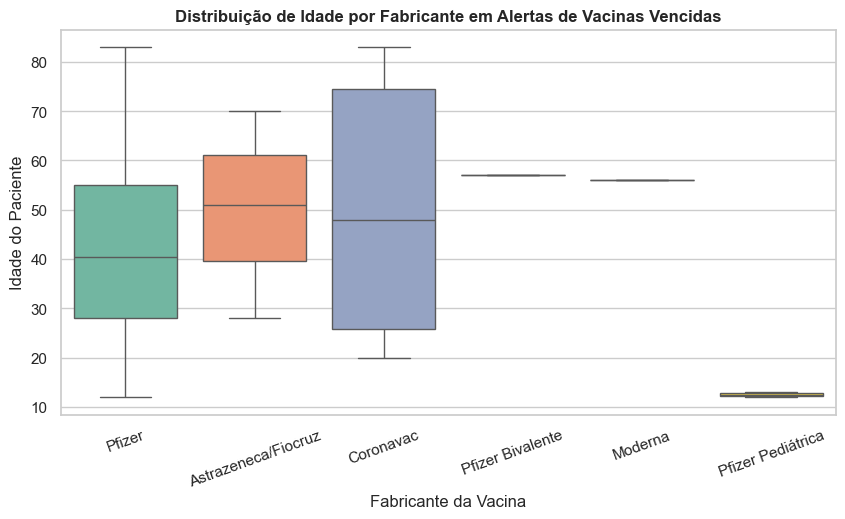

                     count       mean  median
Marca_Primeira_Dose                          
Astrazeneca/Fiocruz     32  50.875000    51.0
Coronavac               10  50.800000    48.0
Moderna                  1  56.000000    56.0
Pfizer                 120  41.816667    40.5
Pfizer Bivalente         1  57.000000    57.0
Pfizer Pediátrica        2  12.500000    12.5


In [2]:
# 1. Filtrando apenas as notificações de vacina vencida
df_vencidas = df[df['Vacinavencida'] == True].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_vencidas, 
    x='Marca_Primeira_Dose', 
    y='Idade Evento', 
    palette='Set2'
)
plt.title('Distribuição de Idade por Fabricante em Alertas de Vacinas Vencidas', fontsize=12, fontweight='bold')
plt.xlabel('Fabricante da Vacina')
plt.ylabel('Idade do Paciente')
plt.xticks(rotation=20)
plt.show()

# Tabela resumo de apoio
print(df_vencidas.groupby('Marca_Primeira_Dose')['Idade Evento'].agg(['count', 'mean', 'median']))

A Pfizer e a AstraZeneca concentram os registros de vencimento. A AstraZeneca apresenta mediana de idade mais alta (~52 anos), enquanto a Pfizer atinge adultos jovens e adolescentes (~36 a 44 anos). Isso reflete a ordem cronológica do plano vacinal: idosos iniciaram com AstraZeneca/CoronaVac, enquanto os grupos mais jovens receberam Pfizer posteriormente. Conforme as notas técnicas da SES-GO, tratam-se em grande parte de falsos alertas causados pela ampliação de validade pela Anvisa.

                                  Vacinaparaidadeinadequada  Doseinadequada  \
Marca_Primeira_Dose Idade Evento                                              
Astrazeneca/Fiocruz 17.0                                  2               0   
Coronavac           17.0                                  1               0   
Pfizer              12.0                                  1               0   
                    14.0                                  0               0   
                    16.0                                  1               0   
                    17.0                                  0               0   
Pfizer Pediátrica   12.0                                  0               0   
                    13.0                                  0               0   

                                  Vacinavencida  
Marca_Primeira_Dose Idade Evento                 
Astrazeneca/Fiocruz 17.0                      0  
Coronavac           17.0                      0  
Pfizer   

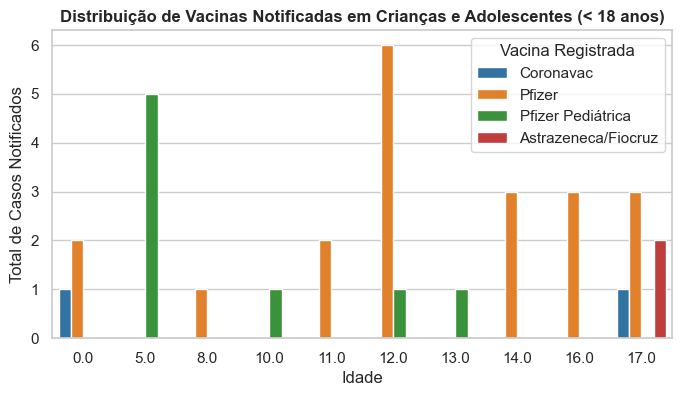

In [3]:
# 2. Filtrando pacientes menores de 18 anos
df_menores = df[df['Idade Evento'] < 18].copy()

# Mapeando tipos de ocorrências registradas em menores
ocorrencias_menores = df_menores.groupby(['Marca_Primeira_Dose', 'Idade Evento'])[['Vacinaparaidadeinadequada', 'Doseinadequada', 'Vacinavencida']].sum()
print(ocorrencias_menores[ocorrencias_menores.sum(axis=1) > 0])

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_menores, 
    x='Idade Evento', 
    hue='Marca_Primeira_Dose', 
    palette='tab10'
)
plt.title('Distribuição de Vacinas Notificadas em Crianças e Adolescentes (< 18 anos)', fontsize=12, fontweight='bold')
plt.xlabel('Idade')
plt.ylabel('Total de Casos Notificados')
plt.legend(title='Vacina Registrada')
plt.show()

Observam-se registros pontuais na faixa dos 5 aos 11 anos e notificações de idade inadequada aos 16/17 anos com AstraZeneca. O fator causador decorre da semelhança visual entre os frascos e da sobrecarga de atendimento nos postos. Em todos os casos, a evolução clínica registrada no dataset permaneceu como Não Grave (Cura sem Sequelas).

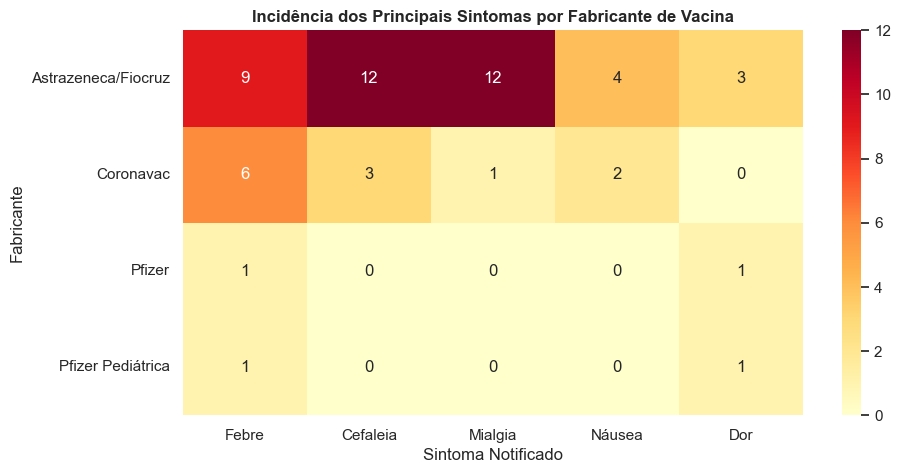

In [4]:
# 3. Principais sintomas clínicos
top_sintomas = ['Febre', 'Cefaleia', 'Mialgia', 'Náusea', 'Dor']

# Agrupando a soma de sintomas por fabricante
sintomas_por_marca = df.groupby('Marca_Primeira_Dose')[top_sintomas].sum()
sintomas_por_marca = sintomas_por_marca[sintomas_por_marca.sum(axis=1) > 0]

plt.figure(figsize=(10, 5))
sns.heatmap(sintomas_por_marca, annot=True, cmap='YlOrRd', fmt='d', cbar=True)
plt.title('Incidência dos Principais Sintomas por Fabricante de Vacina', fontsize=12, fontweight='bold')
plt.xlabel('Sintoma Notificado')
plt.ylabel('Fabricante')
plt.show()

A AstraZeneca/Fiocruz lidera os registros de sintomas sistêmicos transitórios clássicos (Cefaleia, Mialgia e Febre), seguida pela CoronaVac. A Pfizer apresenta baixa frequência de sintomas físicos nos dados locais, pois grande parte de suas notificações foi classificada na categoria de erro administrativo/operacional de dose ou validade em vez de reação adversa (ESAVI).